In [ ]:
!nvidia-smi

Mon Jun 16 06:21:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Unzip images to a custom data folder
!unzip -q /content/data.zip -d /content/custom_data

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2025-06-16 06:21:39--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2025-06-16 06:21:39 (56.0 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 200
Number of annotation files: 200
Images moving to train: 180
Images moving to validation: 20


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 1
names:
- Akar Kentang


In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=60 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 18.4M/18.4M [00:00<00:00, 128MB/s] 
Ultralytics 8.3.155 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, 

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.3.155 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/20 /content/data/validation/images/0cfc4a58-undistorted_2024-07-12_00-50-32.jpg: 256x640 1 Akar Kentang, 163.6ms
image 2/20 /content/data/validation/images/3c0958bb-undistorted_2024-09-13_18-25-16.jpg: 256x640 1 Akar Kentang, 57.9ms
image 3/20 /content/data/validation/images/403bcad2-undistorted_2024-07-31_09-41-58.jpg: 256x640 1 Akar Kentang, 54.5ms
image 4/20 /content/data/validation/images/47499991-undistorted_2024-09-12_12-43-18.jpg: 256x640 1 Akar Kentang, 61.6ms
image 5/20 /content/data/validation/images/57b88afe-undistorted_2024-07-21_19-57-14.jpg: 256x640 1 Akar Kentang, 33.4ms
image 6/20 /content/data/validation/images/703a2b8e-undistorted_2024-09-05_23-03-18.jpg: 256x640 1 Akar Kentang, 16.3ms
image 7/20 /content/data/validation/images/7d93193f-undistorted_2024-09-09_16-53-00.jpg: 256x640 1 Akar Kentang

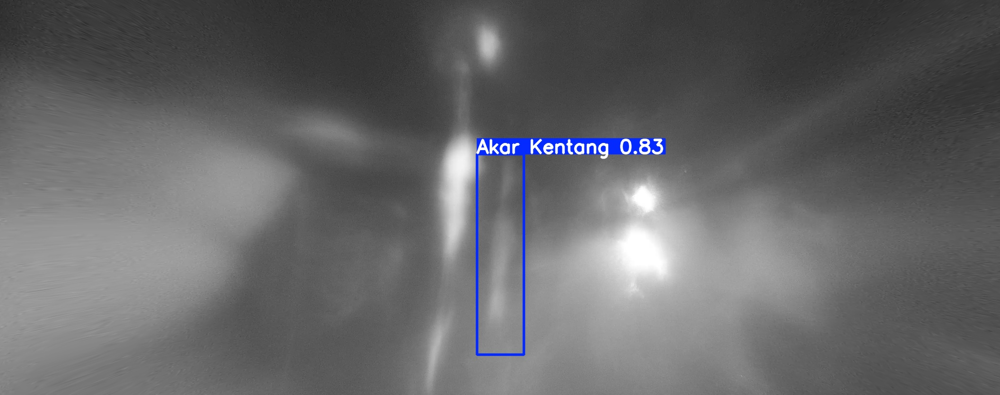

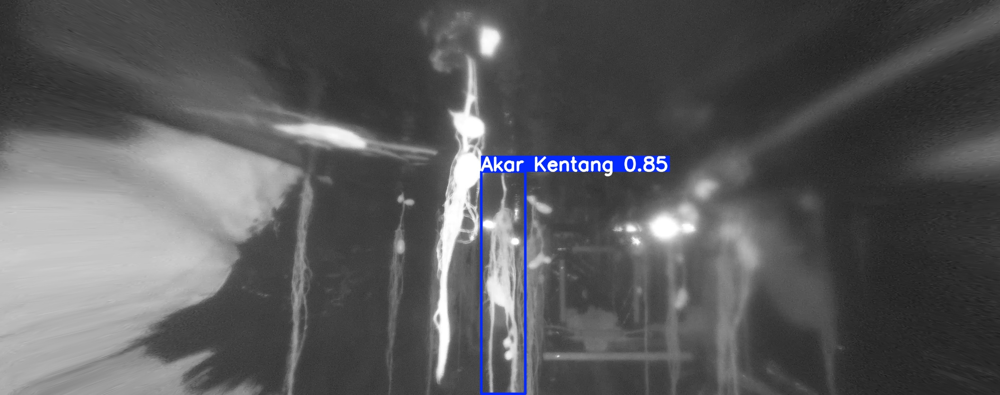

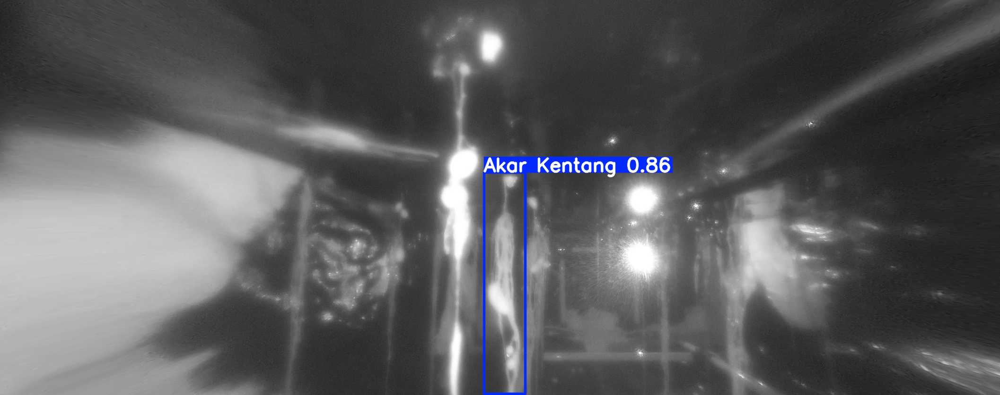

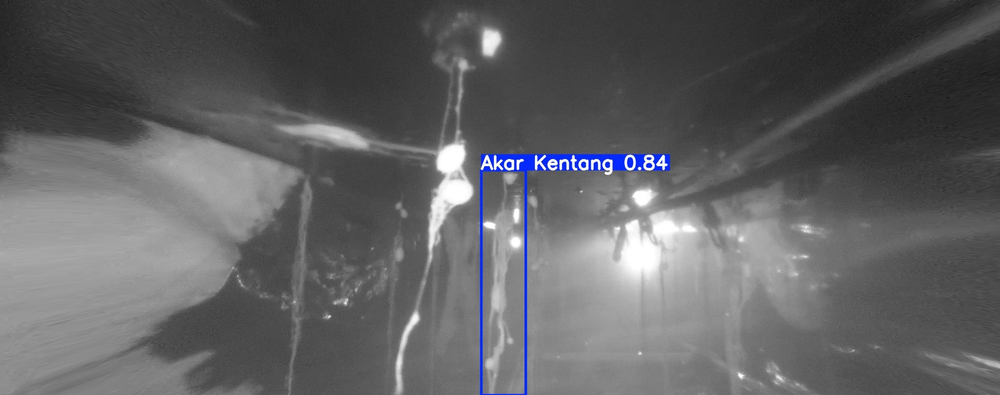

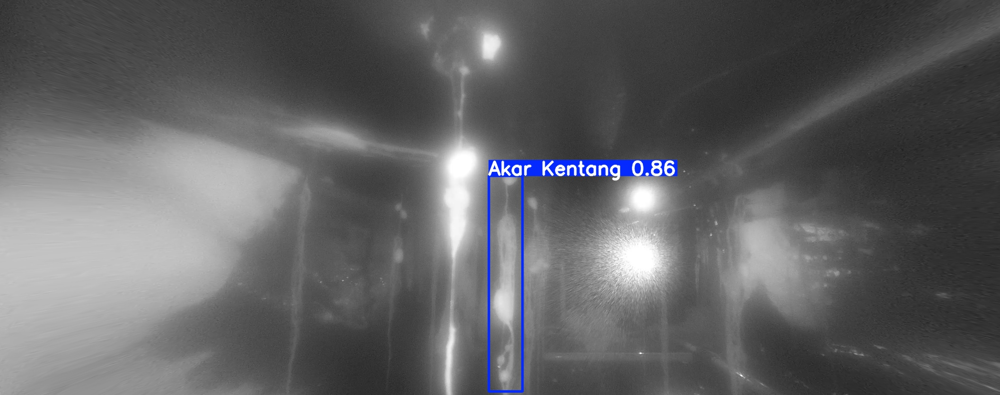

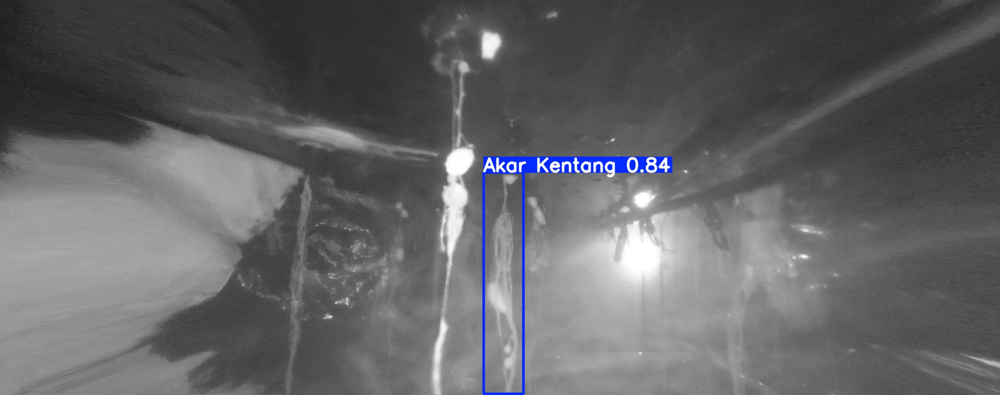

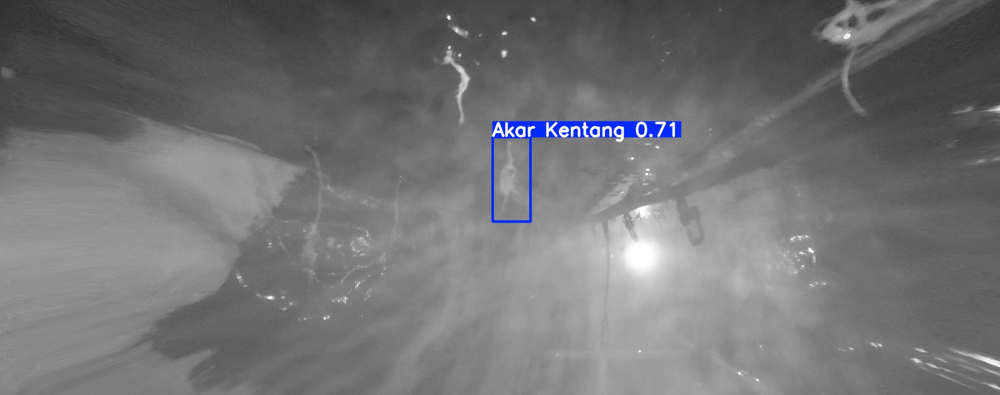

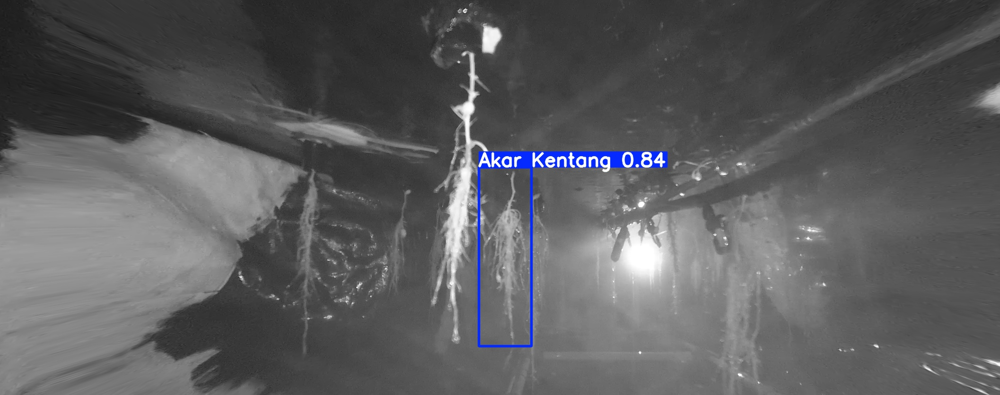

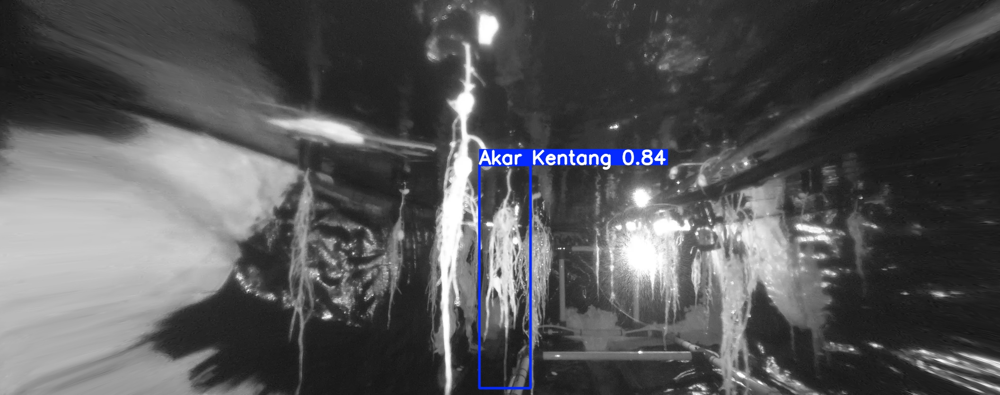

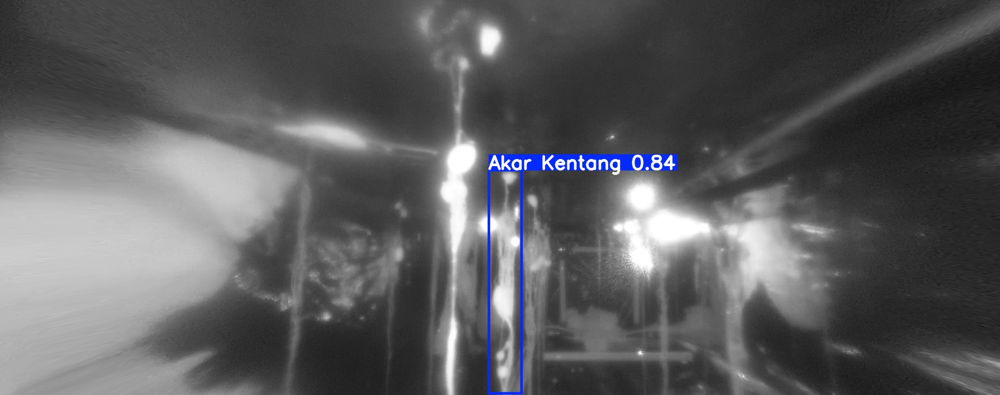

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/R_curve.png (deflated 19%)
  adding: train/train_batch600.jpg (deflated 21%)
  adding: train/train_batch1.jpg (deflated 12%)
  adding: train/results.png (deflated 7%)
  adding: train/train_batch2.jpg (deflated 10%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/val_batch0_labels.jpg (deflated 10%)
  adding: train/args.yaml (deflated 53%)
  adding: train/F1_curve.png (deflated 18%)
  adding: train/train_batch0.jpg (deflated 12%)
  adding: train/confusion_matrix.png (deflated 35%)
  adding: train/train_batch602.jpg (deflated 23%)
  adding: train/confusion_matrix_normalized.png (deflated 36%)
  adding: train/labels.jpg (deflated 52%)
  adding: train/val_batch0_pred.jpg (deflated 10%)
  adding: train/train_batch601.jpg (deflated 24%)
  adding: train/P_curve.png (deflated 24%)
  adding: train/resu

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Define the path to the results.csv file
results_path = '/content/runs/detect/train/results.csv'

# Read the CSV file into a pandas DataFrame
try:
    results_df = pd.read_csv(results_path)
    print("Training Metrics:")
    print(results_df)
except FileNotFoundError:
    print(f"Error: {results_path} not found. Make sure you have trained the model.")
except Exception as e:
    print(f"An error occurred while reading the results file: {e}")

Training Metrics:
    epoch       time  train/box_loss  train/cls_loss  train/dfl_loss  \
0       1    7.40421         2.21334         9.45423         1.80863   
1       2   12.64300         1.32890         3.76545         1.16880   
2       3   16.96740         1.17400         1.61172         1.02626   
3       4   21.35090         1.18628         1.34410         1.04937   
4       5   26.73690         1.21185         1.07883         0.99913   
5       6   31.54170         1.15920         0.98845         0.98939   
6       7   36.90350         1.16500         0.99009         0.98269   
7       8   41.33670         1.14741         0.93113         1.04363   
8       9   45.53680         1.11774         0.95835         1.00634   
9      10   50.39690         1.09304         0.87106         0.97761   
10     11   54.99310         1.09754         0.82223         1.00478   
11     12   59.18350         1.14002         0.80416         0.98699   
12     13   64.14260         1.10046         0

In [ ]:
!pip install ultralytics

import json
import cv2
import torch
import numpy as np

# Define the path to the scale factor file
scale_file_path = '/content/scale.txt' # You can change this path if needed

# Read the pixel-to-cm scale factor from the file
try:
    with open(scale_file_path, 'r') as f:
        pixel_to_cm_scale = float(f.read().strip())
except FileNotFoundError:
    print(f"Error: Scale factor file not found at {scale_file_path}")
    # Set a default value or exit if the file is essential
    pixel_to_cm_scale = 0.0511 # Default value if file not found
    print(f"Using default scale factor: {pixel_to_cm_scale}")
except ValueError:
    print(f"Error: Could not read a valid float from {scale_file_path}")
    # Set a default value or exit if the file content is invalid
    pixel_to_cm_scale = 0.0511 # Default value if file content is invalid
    print(f"Using default scale factor: {pixel_to_cm_scale}")


# Assuming 'results' is the list of Results objects from the prediction
# For example, if you ran the prediction and saved the results to a variable:
# results = model.predict(...)

# If you didn't save the results to a variable, you can re-run the prediction
# and capture the output:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')
results = model.predict(source='data/validation/images', save=False) # Set save=False to avoid re-saving images


# List to store detection results for all images
all_detection_results = []

# Iterate through the results for each image
for result in results:
    # Access the boxes and heights
    boxes = result.boxes
    xyxy = boxes.xyxy # Bounding box coordinates in xyxy format
    heights_pixels = boxes.xywh[:, 3] # Heights in pixels
    heights_cm = heights_pixels * pixel_to_cm_scale # Heights in cm

    # List to store detection results for the current image
    image_detection_results = []

    # Iterate through the detected bounding boxes
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = [int(coord) for coord in xyxy[i]]
        height_cm = heights_cm[i].item() # Get scalar value from tensor

        # Store the detection information
        detection_info = {
            "box_coords": [x1, y1, x2, y2],
            "height_cm": height_cm
        }
        image_detection_results.append(detection_info)

    # Add the results for the current image to the overall list
    all_detection_results.append({
        "image_path": result.path,
        "detections": image_detection_results
    })

# Define the output JSON file path
output_json_path = '/content/detection_results.json' # You can change this path

# Write the collected data to a JSON file
with open(output_json_path, 'w') as f:
    json.dump(all_detection_results, f, indent=4)

print(f"Detection results saved to {output_json_path}")

Error: Scale factor file not found at /content/scale.txt
Using default scale factor: 0.0511

image 1/20 /content/data/validation/images/0cfc4a58-undistorted_2024-07-12_00-50-32.jpg: 256x640 1 Akar Kentang, 49.3ms
image 2/20 /content/data/validation/images/3c0958bb-undistorted_2024-09-13_18-25-16.jpg: 256x640 1 Akar Kentang, 9.3ms
image 3/20 /content/data/validation/images/403bcad2-undistorted_2024-07-31_09-41-58.jpg: 256x640 1 Akar Kentang, 8.9ms
image 4/20 /content/data/validation/images/47499991-undistorted_2024-09-12_12-43-18.jpg: 256x640 1 Akar Kentang, 9.0ms
image 5/20 /content/data/validation/images/57b88afe-undistorted_2024-07-21_19-57-14.jpg: 256x640 1 Akar Kentang, 8.9ms
image 6/20 /content/data/validation/images/703a2b8e-undistorted_2024-09-05_23-03-18.jpg: 256x640 1 Akar Kentang, 9.5ms
image 7/20 /content/data/validation/images/7d93193f-undistorted_2024-09-09_16-53-00.jpg: 256x640 1 Akar Kentang, 9.0ms
image 8/20 /content/data/validation/images/8af947f5-undistorted_2024-09-0

In [ ]:
print(pixel_to_cm_scale)

0.0511


**Reasoning**:
Import the necessary library and iterate through the results to draw bounding boxes and add height text on the images.



Displaying modified images with height annotations:


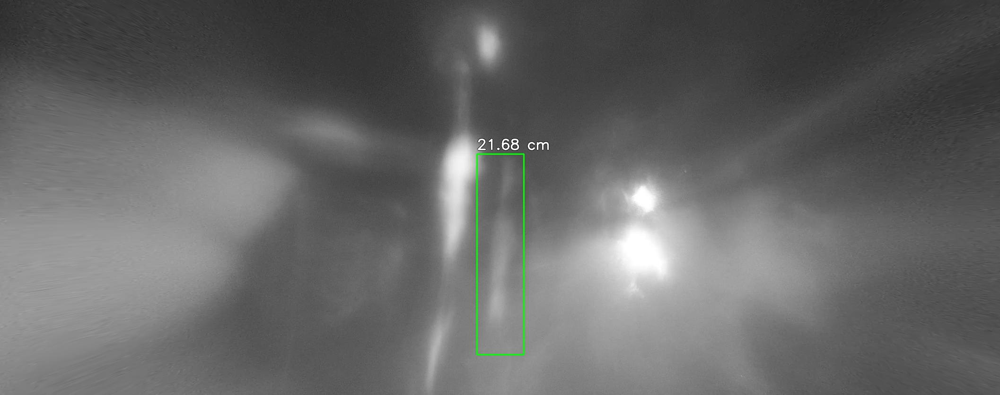

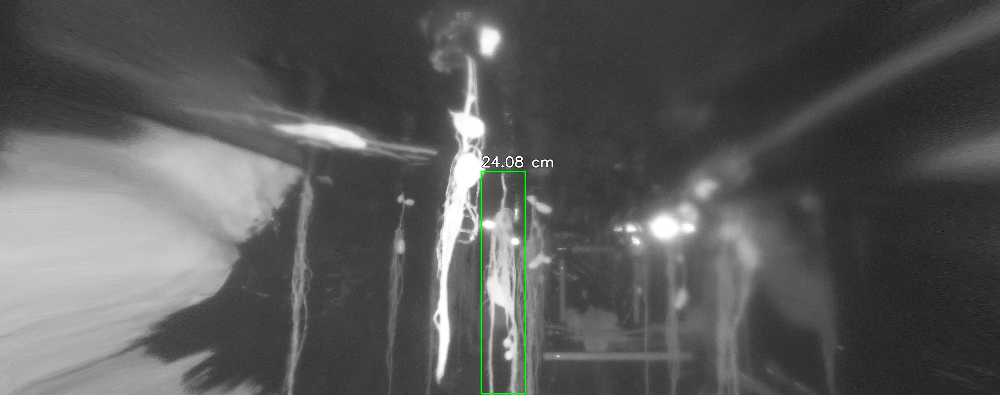

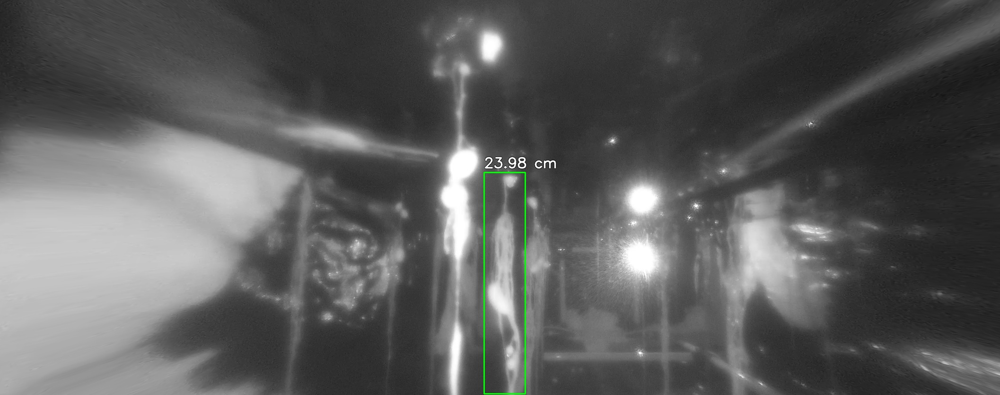

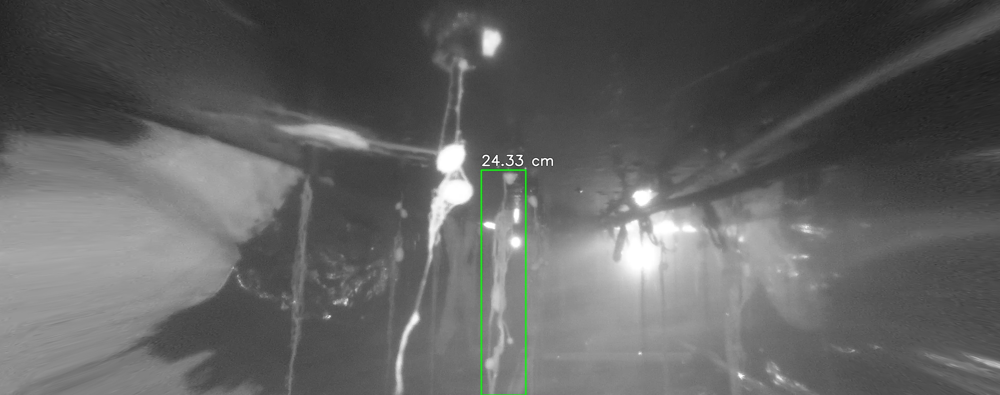

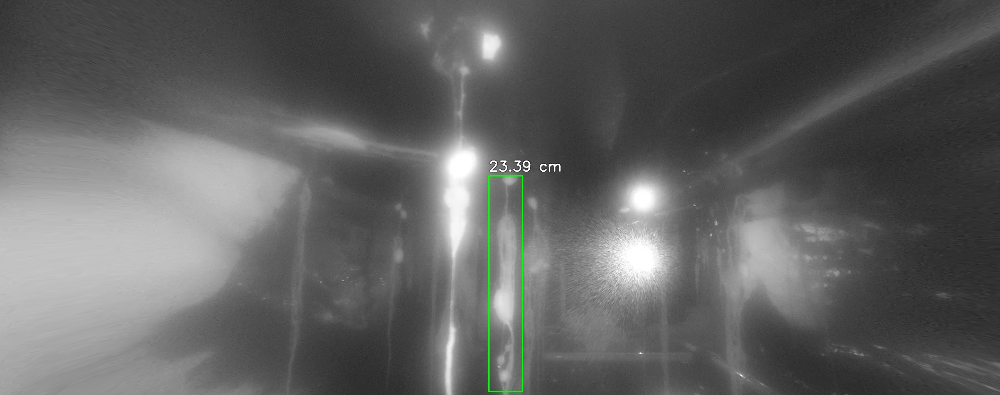

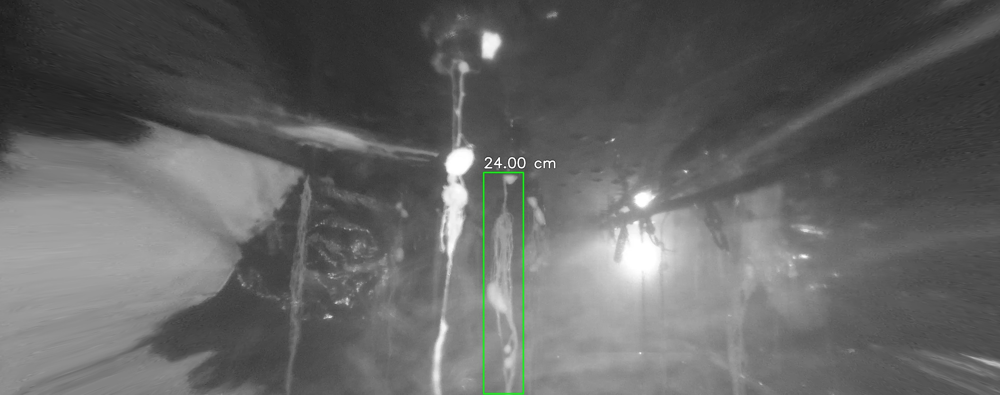

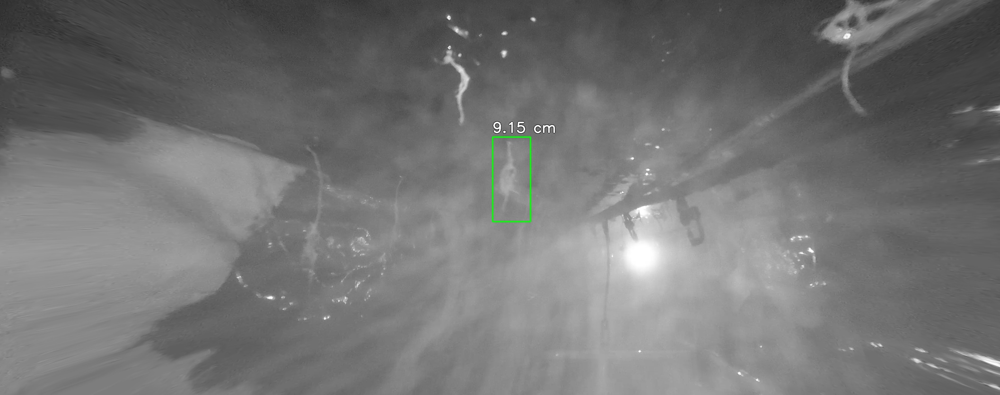

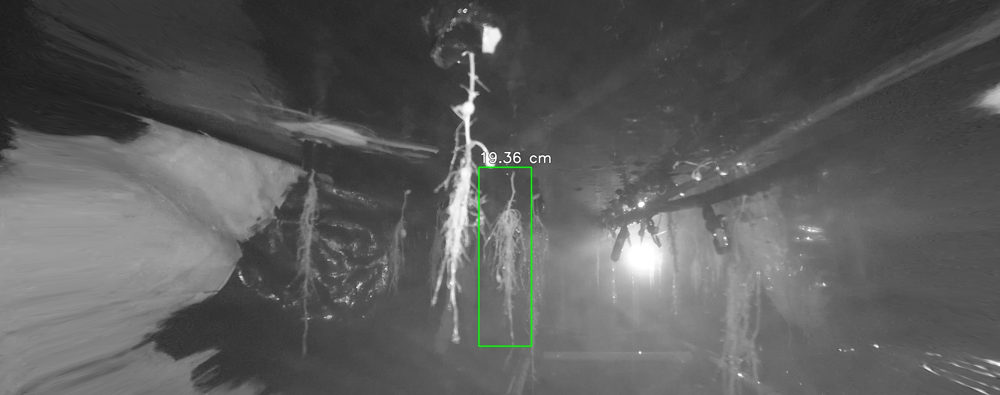

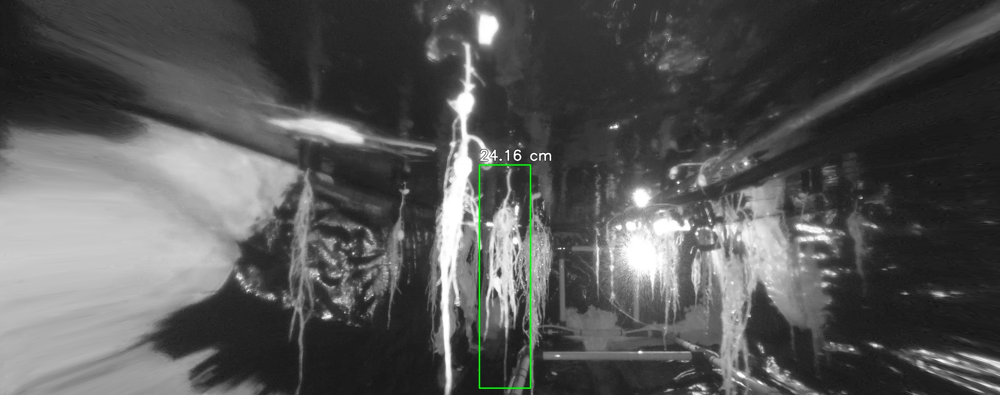

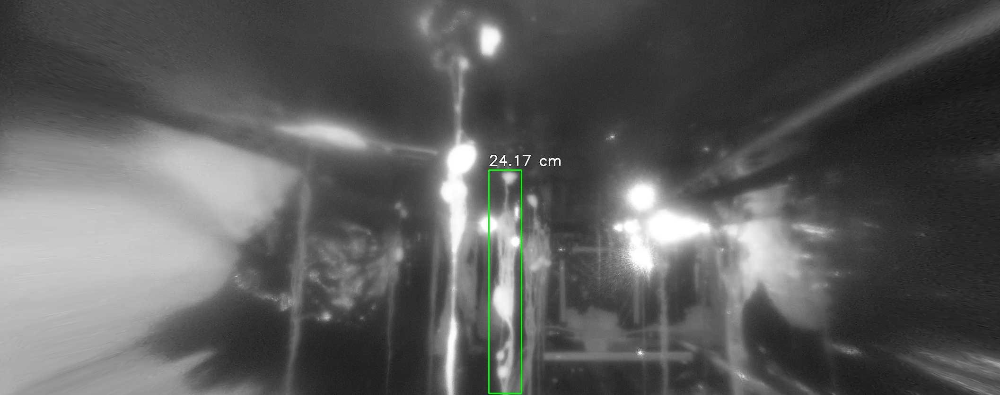

In [ ]:
import cv2
import torch
import numpy as np

# Iterate through the results for each image
for result in results:
    # Load the original image
    image_path = result.path
    image = cv2.imread(image_path)

    if image is None:
        print(f"Warning: Could not load image {image_path}. Skipping.")
        continue

    # Access the boxes and heights
    boxes = result.boxes
    xyxy = boxes.xyxy # Bounding box coordinates in xyxy format
    heights_pixels = boxes.xywh[:, 3] # Heights in pixels
    heights_cm = heights_pixels * pixel_to_cm_scale # Heights in cm

    # Iterate through the detected bounding boxes
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = [int(coord) for coord in xyxy[i]]
        height_cm = heights_cm[i].item() # Get scalar value from tensor

        # Draw rectangle on the image
        color = (0, 255, 0) # Green color
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)

        # Format the height text
        height_text = f"{height_cm:.2f} cm"

        # Determine text position (above the bounding box)
        text_x = x1
        text_y = y1 - 10 # 10 pixels above the top-left corner

        # Ensure text is within image boundaries
        if text_y < 0:
            text_y = y1 + 20 # 20 pixels below the top-left corner

        # Put the formatted height text on the image
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.0 # Increased font scale
        font_thickness = 2 # Increased font thickness
        text_color = (255, 255, 255) # White color with black outline for visibility
        text_color_outline = (0, 0, 0)

        # Add black outline
        cv2.putText(image, height_text, (text_x, text_y), font, font_scale, text_color_outline, font_thickness + 2, cv2.LINE_AA)
        # Add white text
        cv2.putText(image, height_text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)


    # Save or display the modified image
    # For simplicity, we'll overwrite the original image in the validation folder
    # In a real scenario, you might want to save to a different directory
    cv2.imwrite(image_path, image)

# After processing all images, you can display the modified images as in the previous cell
import glob
from IPython.display import Image, display

# Clean up previous prediction results to avoid mixing old and new images
!rm -rf /content/runs/detect/predict_modified/
!mkdir /content/runs/detect/predict_modified/

# Move the modified images to a new directory for display
import shutil
for image_path in glob.glob(f'/content/data/validation/images/*.jpg'):
    shutil.copy(image_path, '/content/runs/detect/predict_modified/')

print("Displaying modified images with height annotations:")
for image_path in glob.glob(f'/content/runs/detect/predict_modified/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')